In [7]:
import matplotlib.pyplot as plt
import torch
from torch import nn, optim, tensor

## Generating Data

### Exercises

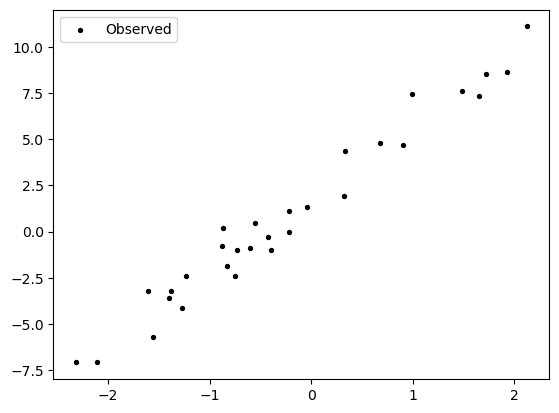

In [224]:
torch.manual_seed(42)

# Generate Data
n_samples = 30
x = torch.randn(n_samples) 
noise = torch.randn(n_samples)
y_obs = 4 * x + 2 + noise

plt.scatter(x, y_obs, 8, 'k', label='Observed')
plt.legend();

## Modeling Data: Linear Regression

### Exercises

#### Util Functions


In [ ]:
def generate_data() -> tensor:
    n_samples = 30
    x = torch.randn(n_samples) 
    noise = torch.randn(n_samples)
    y_obs = 4 * x + 2 + noise
    return x, y_obs



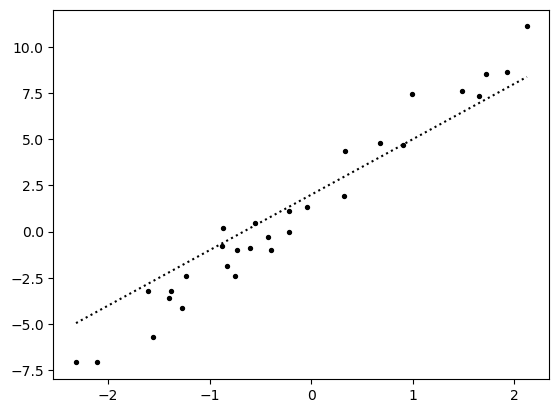

In [296]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
def model(x):
    return 3 * x + 2
    
# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model(x0), ':k');

## Comparing the Model's Predictions to the Observed Data: "Loss"

### Exercises

#### Util Functions

In [279]:
def linear_model(weight, bias):
    def model(x):
        return weight * x + bias
    return model

Text(0.5, 1.0, 'Loss: 0.83')

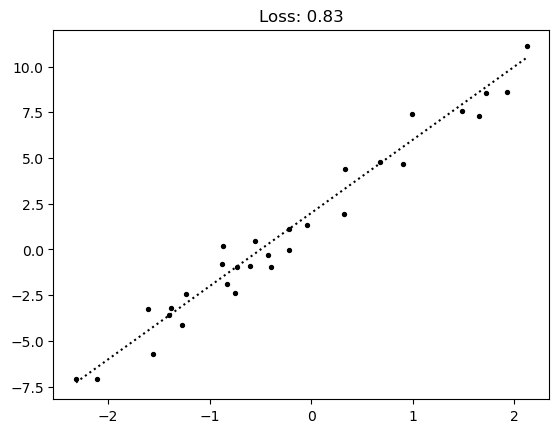

In [299]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
model = linear_model(weight=4, bias=2)
    
# Check the Model's Predictions Against the Observed Data
y_pred = model(x)
loss = (y_pred - y_obs).square().mean()

# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model(x0), ':k');
plt.title(f'Loss: {loss.item():.2}')

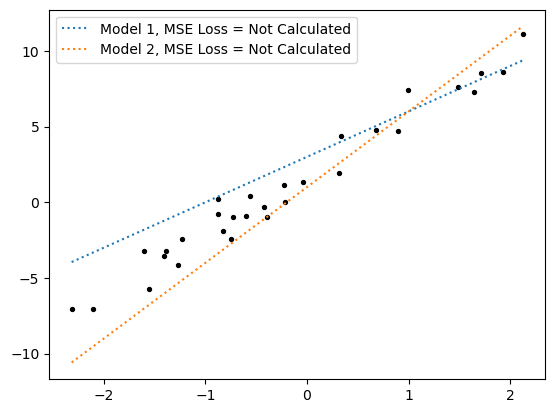

In [328]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
model1 = linear_model(weight=3, bias=3)
model2 = linear_model(weight=5, bias=1)
    
# Check the Model's Predictions Against the Observed Data
y_pred1 = model1(x)
y_pred2 = model2(x)
loss1 = 0. #(y_pred1 - y_obs).square().mean()
loss2 = 0. #(y_pred2 - y_obs).square().mean()

# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model1(x0), ':', label=f'Model 1, MSE Loss = {round(loss1, 2) if loss1 else 'Not Calculated'}');
plt.plot(x0, model2(x0), ':', label=f'Model 2, MSE Loss = {round(loss2, 2) if loss2 else 'Not Calculated'}');
plt.legend();


## Improving the Model: Minimizing Loss By Modifying Model Parameters

### Utils

In [332]:
loss_function = nn.MSELoss()

### Exercises

In [ ]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
model = linear_model(weight=4, bias=2)
    
# Check the Model's Predictions Against the Observed Data
y_pred = model(x)
loss = (y_pred - y_obs).square().mean()

# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model(x0), ':k');
plt.title(f'Loss: {loss.item():.2}')

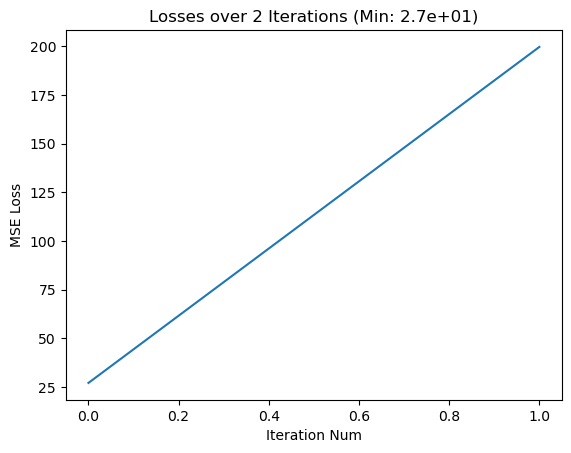

In [364]:
torch.manual_seed(42)

# Generate Data
x, y_obs = generate_data()

# Update the Model Parameters
num_iterations = 2  # UPDATE ME!

losses = []
for iteration in range(1, num_iterations + 1):

    # Randomly Guess the Model Parameters
    weight = torch.empty(1).uniform_(-10, 10)
    bias = torch.empty(1).uniform_(-10, 10)

    # Check the Model's Predictions Against the Observed Data
    model = linear_model(weight, bias)
    y_pred = model(x)
    loss = loss_function(y_pred, y_obs)
    losses.append(loss)


# Plot the Loss for each Iteration
plt.plot(losses)
plt.title(f'Losses over {iteration} Iterations (Min: {min(losses):.2})')
plt.xlabel('Iteration Num')
plt.ylabel('MSE Loss');



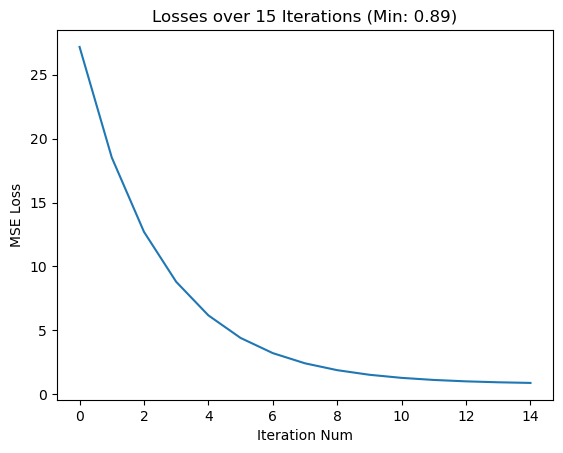

In [368]:
torch.manual_seed(42)

# Generate Data
x, y_obs = generate_data()

# Randomly Guess the Model Parameters
num_iterations = 15  # UPDATE ME!

weight = torch.empty(1).uniform_(-10, 10).requires_grad_()
bias = torch.empty(1).uniform_(-10, 10).requires_grad_()

losses = []
for iteration in range(1, num_iterations + 1):

    # Forward Pass: Check the Model's Predictions
    if weight.grad is not None:
        weight.grad.zero_()
    if bias.grad is not None:
        bias.grad.zero_()

    model = linear_model(weight, bias)
    y_pred = model(x)
    loss = loss_function(y_pred, y_obs)
    losses.append(loss)

    # Backward Pass: Improve the Model based on the Loss Gradient
    loss.backward()  
    with torch.no_grad():
        weight -= weight.grad * .1
        bias -= bias.grad * .1


# Plot the Loss for each Iteration
plt.plot(tensor(losses))
plt.title(f'Losses over {iteration} Iterations (Min: {min(losses):.2})')
plt.xlabel('Iteration Num')
plt.ylabel('MSE Loss');

